# Rapport d'Étude : Analyse Statistique et Suivi des Capteurs Industriels

Module : SAÉ 204 - Base de données et Statistiques (BUT Informatique 1ère année)
Groupe : Ouameur Aïssa, Ounays Mayeux, Alban Platel.

Introduction

On a travaillé sur ce projet pour voir comment suivre l’état des capteurs dans une usine. Aujourd’hui, les mesures sont encore vérifiées à la main, ce qui prend du temps et peut provoquer des erreurs.

L’idée du projet est de :

- détecter automatiquement les erreurs de mesure avec Python.
- garder un historique des capteurs dans PostgreSQL pour mieux suivre leur état.

**Dictionnaire de données**

Avant de commencer, on a regardé la structure de la base pour comprendre comment les données sont organisées. Le dictionnaire de données sert surtout à repérer les tables importantes, leurs champs, et les liens entre elles.

| table\_name | column\_name | data\_type | is\_nullable |
| :--- | :--- | :--- | :--- |
| controller | controllerid | integer | NO |
| controller | modelid | integer | NO |
| controller | serialnumber | text | NO |
| controlmeasurement | sensorid | integer | NO |
| controlmeasurement | controllerid | integer | NO |
| controlmeasurement | sensortimestamp | timestamp without time zone | NO |
| controlmeasurement | controltimestamp | timestamp without time zone | NO |
| controlmeasurement | controlvalue | double precision | NO |
| model | unit | text | NO |
| model | modelid | integer | NO |
| model | brand | text | NO |
| model | model | text | NO |
| model | name | text | NO |
| sensor | validity | interval | NO |
| sensor | sensorid | integer | NO |
| sensor | serialnumber | text | NO |
| sensor | position | text | NO |
| sensor | modelid | integer | NO |
| sensormeasurement | timestamp | timestamp without time zone | NO |
| sensormeasurement | sensorid | integer | NO |
| sensormeasurement | sensorvalue | double precision | NO |


**2-Test de connexion**

Pour ce projet, on a d’abord exporté la base distante afin de l’utiliser en local. Ça nous a permis de travailler plus facilement, sans dépendre du réseau, et d’avoir les droits nécessaires pour tester nos requêtes.

Le script ci-dessous montre la connexion entre Python et PostgreSQL avec la bibliothèque psycopg.

In [8]:
import psycopg

conn_params = {
    "host": "localhost",
    "dbname": "postgres",
    "user": "postgres",
    "password": "admin"
}

try:
    with psycopg.connect(**conn_params) as conn:
        print("Connection successful!")
        with conn.cursor() as cur:
            cur.execute("SELECT version();")
            print(cur.fetchone())
except psycopg.OperationalError as e:
    print(f"Connection failed: {e}")


Connection successful!
('PostgreSQL 18.3 on x86_64-windows, compiled by msvc-19.44.35225, 64-bit',)


Le résultat confirme que la connexion fonctionne. On peut donc passer à la suite.

**Script 1  - Extraction des erreurs brutes**                    Avant de faire des calculs statistiques, on commence par observer les données brutes. Pour mesurer la précision d’un capteur, on compare ses valeurs avec celles du contrôle. L’erreur est calculée avec controlvalue - sensorvalue.

Le script suivant fait la jointure entre sensormeasurement et controlmeasurement, puis affiche les premières erreurs pour chaque capteur.

In [9]:
import psycopg

def get_all_sensor_ids(conn):
    with conn.cursor() as cur:
        cur.execute("SELECT DISTINCT sensorid FROM sensormeasurement ORDER BY sensorid;")
        return [row[0] for row in cur.fetchall()]

def test_single_sensor(conn, sensor_id):
    with conn.cursor() as cur:
        cur.execute("""
            SELECT sensormeasurement.sensorid,
                   controlmeasurement.controlvalue - sensormeasurement.sensorvalue AS diff
            FROM controlmeasurement
            JOIN sensormeasurement
                ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
               AND controlmeasurement.sensorid = sensormeasurement.sensorid
            WHERE controlmeasurement.sensorid = %s
            ORDER BY controlmeasurement.controltimestamp
            LIMIT 50;
        """, (sensor_id,))

        results = cur.fetchall()

        print(f"\n--- Testing Sensor {sensor_id} ---")
        if not results:
            print("No data found.")
            return

        for row in results:
            print(f"Sensor {row[0]} | Difference: {row[1]}")

if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    with psycopg.connect(**conn_params) as conn:
        sensor_ids = get_all_sensor_ids(conn)

        for s_id in sensor_ids:
            test_single_sensor(conn, s_id)


--- Testing Sensor 1 ---
Sensor 1 | Difference: -0.6928256070072949
Sensor 1 | Difference: -0.42472458437324756
Sensor 1 | Difference: -0.19717837492203405
Sensor 1 | Difference: -0.05734016940635911
Sensor 1 | Difference: 0.14345425626137076
Sensor 1 | Difference: -0.37765161701976624
Sensor 1 | Difference: -0.38994523019952476
Sensor 1 | Difference: 0.4336675151979643
Sensor 1 | Difference: 0.7761312024213797
Sensor 1 | Difference: -0.15902853772262193
Sensor 1 | Difference: -0.0590040671430998
Sensor 1 | Difference: 0.4418077118033801
Sensor 1 | Difference: 0.5576625971798089
Sensor 1 | Difference: -0.02724000068365151
Sensor 1 | Difference: -0.0610747926891686
Sensor 1 | Difference: -0.14927230955878212
Sensor 1 | Difference: 0.3453796731956025
Sensor 1 | Difference: 0.565314546846384
Sensor 1 | Difference: 0.19167603339857386
Sensor 1 | Difference: 0.8958946595656778
Sensor 1 | Difference: -0.1490143137199928
Sensor 1 | Difference: -0.08535771270845571
Sensor 1 | Difference: -0.1

Analyse des erreurs brutes

En regardant les erreurs des 7 capteurs, on voit rapidement que tous ne se comportent pas de la même façon.

Les capteurs 1 et 6 sont les plus stables. Leurs erreurs restent faibles et proches de zéro.

Les capteurs 2, 3 et 7 sont plus bruités. On voit plus d’écarts, parfois assez grands.

Le capteur 5 semble instable. Les erreurs deviennent rapidement plus dispersées.

Le capteur 4 est clairement le plus problématique. Ses valeurs sont très éloignées de la normale et il paraît difficile à exploiter.

Calcul de la moyenne et de l’écart-type

Après cette première observation, on calcule la moyenne et l’écart-type des erreurs pour chaque capteur. La moyenne permet de voir s’il y a un biais, et l’écart-type montre à quel point les mesures sont dispersées. Ces deux valeurs servent ensuite à définir les limites de tolérance.

In [10]:
import psycopg

def get_all_sensor_ids(conn):
    with conn.cursor() as cur:
        cur.execute("""
            SELECT DISTINCT sensorid
            FROM sensormeasurement
            ORDER BY sensorid;
        """)
        rows = cur.fetchall()
        return [row[0] for row in rows]

def get_sensor_statistics(conn, sensor_id):
    with conn.cursor() as cur:
        cur.execute("""
            SELECT
                AVG(cm.controlvalue - sm.sensorvalue) AS avg_diff,
                STDDEV(cm.controlvalue - sm.sensorvalue) AS stddev_diff
            FROM sensormeasurement sm
            JOIN controlmeasurement cm
                ON sm.sensorid = cm.sensorid
               AND sm.timestamp = cm.sensortimestamp
            WHERE sm.sensorid = %s;
        """, (sensor_id,))

        row = cur.fetchone()

    print(f"\n--- Statistics for Sensor {sensor_id} ---")

    if row and row[0] is not None:
        mean = float(row[0])
        stddev = float(row[1]) if row[1] is not None else 0.0

        print(f"Average (error): {mean:.10f} | StdDev (error): {stddev:.10f}")

        return mean, stddev
    else:
        print("No data found or insufficient data to compute statistics.")
        return None, None

if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    try:
        with psycopg.connect(**conn_params) as conn:
            sensor_ids = get_all_sensor_ids(conn)

            for s_id in sensor_ids:
                get_sensor_statistics(conn, s_id)

    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")


--- Statistics for Sensor 1 ---
Average (error): -0.0037443199 | StdDev (error): 0.4127852187

--- Statistics for Sensor 2 ---
Average (error): -0.0315614823 | StdDev (error): 0.7388302019

--- Statistics for Sensor 3 ---
Average (error): -0.0203389265 | StdDev (error): 0.6631105094

--- Statistics for Sensor 4 ---
Average (error): -0.0397408049 | StdDev (error): 2.3860054951

--- Statistics for Sensor 5 ---
Average (error): -0.1031293582 | StdDev (error): 1.3965594563

--- Statistics for Sensor 6 ---
Average (error): -0.0084053747 | StdDev (error): 0.1227674919

--- Statistics for Sensor 7 ---
Average (error): -0.0337729137 | StdDev (error): 0.5360308385


Analyse globale des statistiques du parc

En regardant l’ensemble de l’historique, on voit d’abord que les moyennes μμ de tous les capteurs sont très proches de 0. Cela veut dire qu’il n’y a pas de biais constant important sur les mesures.

Mais la moyenne ne suffit pas pour juger un capteur. Pour savoir s’il est fiable ou non, il faut aussi regarder l’écart-type σσ, qui montre à quel point les mesures sont dispersées autour de la moyenne.

    Les capteurs les plus stables (capteurs 6 et 1)
        Le capteur 6 est le plus régulier du parc, avec un écart-type très faible (σ=0.1228).
        Le capteur 1 reste lui aussi très correct (σ=0.4128).

    Les capteurs avec un bruit moyen (capteurs 7, 3 et 2)
        Ces trois capteurs restent centrés autour de zéro, mais leurs valeurs sont un peu plus dispersées.
        Leur écart-type est compris entre σ=0.5360 et σ=0.7388.
        Ils restent exploitables, mais ils sont moins précis que les deux premiers.

    Le capteur très bruité (capteur 5)
        Le capteur 5 a un écart-type élevé (σ=1.3966).
        Même si sa moyenne reste correcte, ses mesures sont beaucoup trop dispersées pour être vraiment fiables.

    Le capteur le plus dégradé (capteur 4)
        Le capteur 4 a l’écart-type le plus élevé (σ=2.3860).
        Ses mesures sont trop éloignées les unes des autres pour être utilisées correctement dans un contexte industriel.

Choix du capteur pour l’analyse approfondie

Après avoir étudié le parc, on a choisi de travailler sur le capteur 3 pour la suite. Il n’est pas le plus stable, mais il n’est pas non plus complètement hors service, donc il reste intéressant à analyser.

Ce capteur présente un bruit assez visible et quelques valeurs qui s’écartent du comportement attendu. C’est justement ce qui en fait un bon exemple pour tester les cartes de contrôle et les méthodes de détection.

**Script 3 — Génération de la carte de contrôle (capteur 3)**

Le script suivant permet de tracer la carte de contrôle du capteur 3. On y ajoute les limites calculées à partir des statistiques du capteur :

    La moyenne, qui sert de ligne centrale.

    Les limites d’avertissement, fixées à ±1σ.

    Les limites de contrôle, fixées à ±2σ. Toute valeur qui dépasse cette zone est considérée comme anormale.

--- Analyzing Target Sensor 3 ---
Population Mean (µ): -0.020339
Standard Deviation (σ): 0.663111

--- Extractions des 30 derniers points pour la carte ---
Timestamp: 2024-03-02 17:30:28.641396 | Error: -0.833214
Timestamp: 2024-03-03 10:48:18.203447 | Error: 0.748897
Timestamp: 2024-03-04 12:07:29.795239 | Error: -0.644218
Timestamp: 2024-03-05 06:41:33.152289 | Error: 0.229004
Timestamp: 2024-03-06 03:07:33.304777 | Error: 0.011157
Timestamp: 2024-03-07 03:27:09.444855 | Error: -0.079422
Timestamp: 2024-03-08 11:26:41.589513 | Error: -0.020070
Timestamp: 2024-03-09 10:57:54.918260 | Error: -0.648503
Timestamp: 2024-03-10 10:22:55.582293 | Error: 0.424096
Timestamp: 2024-03-11 08:18:34.225814 | Error: -0.451191
Timestamp: 2024-03-12 17:19:05.230152 | Error: -1.267758
Timestamp: 2024-03-13 10:10:03.181395 | Error: 0.515277
Timestamp: 2024-03-13 19:43:47.815111 | Error: 0.938742
Timestamp: 2024-03-15 06:00:10.570996 | Error: -0.592378
Timestamp: 2024-03-16 06:53:03.593570 | Error: 0.219

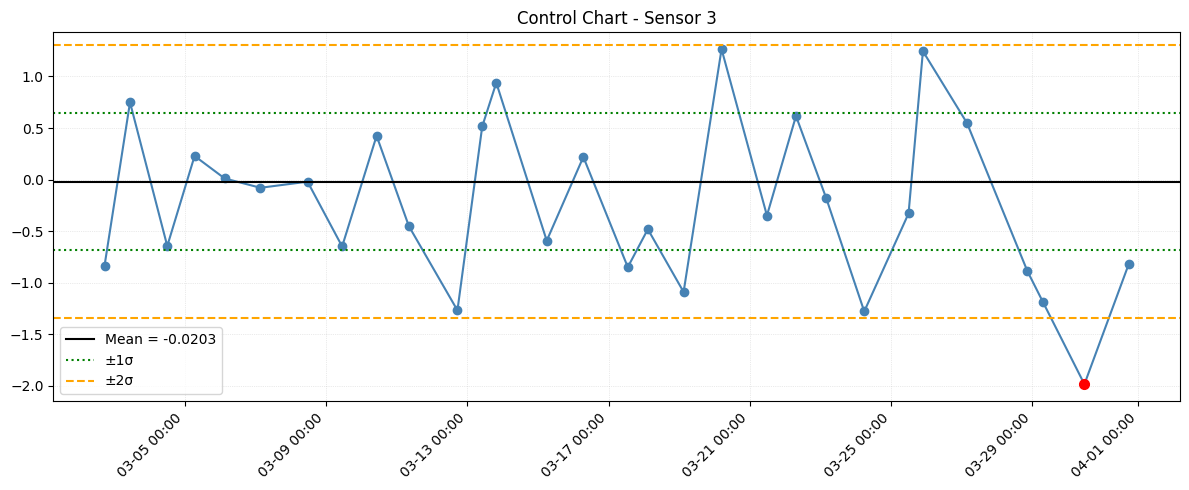

In [11]:
import psycopg

TARGET_SENSOR = 3
MAX_POINTS = 100
MIN_POINTS = 20

def get_sensor_statistics(conn, sensor_id):
    """Calculate the population mean and standard deviation for the sensor."""
    with conn.cursor() as cursor:
        cursor.execute("""
            SELECT AVG(cm.controlvalue - sm.sensorvalue),
                   STDDEV(cm.controlvalue - sm.sensorvalue)
            FROM controlmeasurement cm
            JOIN sensormeasurement sm
              ON cm.sensortimestamp = sm.timestamp
             AND cm.sensorid = sm.sensorid
            WHERE cm.sensorid = %s
        """, (sensor_id,))
        row = cursor.fetchone()
        if not row or row[0] is None:
            return None, None
        return float(row[0]), float(row[1])

def get_recent_errors(conn, sensor_id):
    """Fetch recent measurements using dynamic windowing."""
    with conn.cursor() as cursor:
        for days in [8, 30, 90]:
            cursor.execute("""
                SELECT cm.controlvalue - sm.sensorvalue, cm.controltimestamp
                FROM controlmeasurement cm
                JOIN sensormeasurement sm
                  ON cm.sensortimestamp = sm.timestamp
                 AND cm.sensorid = sm.sensorid
                WHERE cm.sensorid = %s
                  AND cm.controltimestamp >= (
                      SELECT MAX(controltimestamp) - INTERVAL '1 day' * %s
                      FROM controlmeasurement WHERE sensorid = %s
                  )
                ORDER BY cm.controltimestamp DESC
                LIMIT %s
            """, (sensor_id, days, sensor_id, MAX_POINTS))

            rows = cursor.fetchall()
            if len(rows) >= MIN_POINTS:
                rows.reverse()
                return rows
        rows.reverse()
        return rows

def plot_control_chart(data, mean, standard_deviation, sensor_id):
    """Plot the control chart with statistical bounds."""
    timestamps = [row[1] for row in data]
    errors = [float(row[0]) for row in data]

    figure, axis = plt.subplots(figsize=(12, 5))
    axis.plot(timestamps, errors, marker='o', linestyle='-', color='steelblue')

    for ts, err in zip(timestamps, errors):
        if not (mean - 2 * standard_deviation <= err <= mean + 2 * standard_deviation):
            axis.plot(ts, err, 'ro', markersize=7)

    axis.axhline(mean, color='black', linewidth=1.5, label=f'Mean = {mean:.4f}')
    axis.axhline(mean + standard_deviation, color='green', linestyle=':', label=f'±1σ')
    axis.axhline(mean - standard_deviation, color='green', linestyle=':')
    axis.axhline(mean + 2 * standard_deviation, color='orange', linestyle='--', label=f'±2σ')
    axis.axhline(mean - 2 * standard_deviation, color='orange', linestyle='--')

    axis.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.xticks(rotation=45, ha='right')
    axis.set_title(f'Control Chart - Sensor {sensor_id}')
    axis.legend()
    axis.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    db_credentials = {"host": "localhost", "dbname": "postgres", "user": "postgres", "password": "admin"}
    try:
        with psycopg.connect(**db_credentials) as conn:
            print(f"--- Analyzing Target Sensor {TARGET_SENSOR} ---")
            mean, std_dev = get_sensor_statistics(conn, TARGET_SENSOR)

            if mean is not None:
                print(f"Population Mean (µ): {mean:.6f}")
                print(f"Standard Deviation (σ): {std_dev:.6f}\n")

                recent_data = get_recent_errors(conn, TARGET_SENSOR)
                if recent_data:
                    print(f"--- Extractions des {len(recent_data)} derniers points pour la carte ---")
                    for row in recent_data:
                        print(f"Timestamp: {row[1]} | Error: {float(row[0]):.6f}")
                    print("------------------------------------------------------------------\n")

                    plot_control_chart(recent_data, mean, std_dev, TARGET_SENSOR)
    except psycopg.OperationalError as error:
        print(f"Database connection error: {error}")

**Validation de l’échantillonnage dynamique et analyse visuelle**

Le script a d’abord essayé de récupérer 8 jours de données, mais ce n’était pas suffisant pour le capteur 3. Il a donc automatiquement élargi la fenêtre à 30 jours, ce qui a permis d’obtenir 30 points de contrôle.

Sur la carte, la moyenne reste très proche de zéro, donc il n’y a pas de gros décalage sur les mesures. En revanche, on remarque une valeur anormale le 30 mars 2024, avec une erreur de -1.98. Cette valeur montre qu’un suivi automatique peut être utile pour repérer rapidement ce genre d’écart.

**Validation empirique de la loi normale**

Ensuite, on a vérifié si les erreurs du capteur 3 suivent bien une loi normale. Pour ça, on a regardé combien de points se trouvent dans les zones ±1σ±1σ, ±2σ±2σ et ±3σ±3σ.

Les résultats obtenus sont très proches de ceux qu’on attend théoriquement pour une distribution normale. On peut donc dire que le modèle gaussien colle bien aux données du capteur 3


--- SENSOR 3 ERROR STATS ---
Total points evaluated: 456
Mean (µ): 0.020339 | Standard Deviation (σ): 0.663111

Q1: Points within [-1σ, +1σ]
Count: 313 / 456 -> 68.64% (Expected: ~68.27%)

Q2: Points within [-2σ, +2σ]
Count: 435 / 456 -> 95.39% (Expected: ~95.45%)

Q3: Points within [-3σ, +3σ]
Count: 455 / 456 -> 99.78% (Expected: ~99.73%)



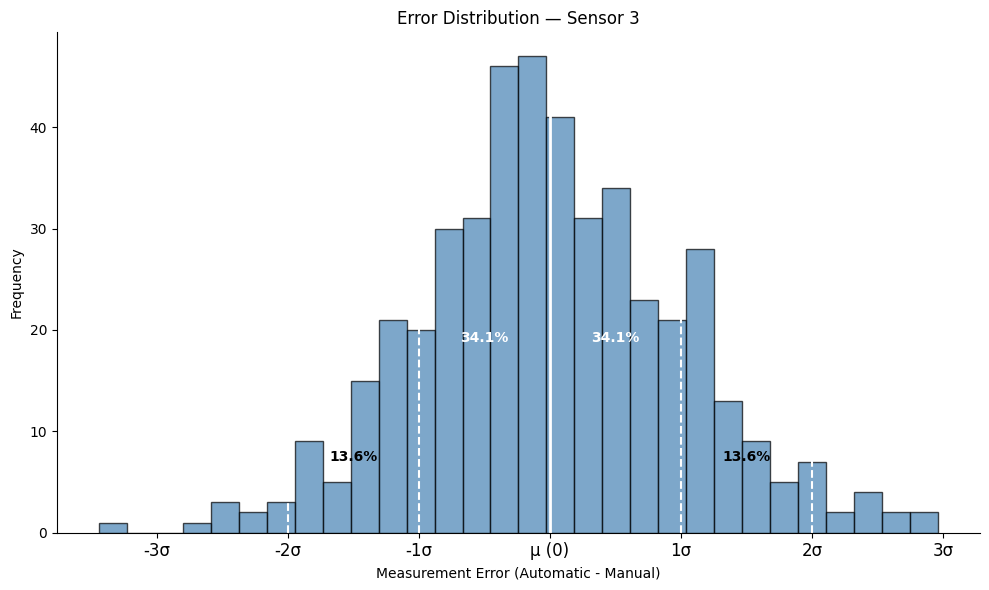

In [12]:
import psycopg
import matplotlib.pyplot as plt

TARGET_SENSOR = 3

def analyze_target_sensor_error(conn, sensor_id):
    with conn.cursor() as cur:
        cur.execute("""
            WITH ErrorData AS (
                SELECT (sm.sensorvalue - cm.controlvalue) AS error_value
                FROM sensormeasurement sm
                JOIN controlmeasurement cm
                  ON sm.sensorid = cm.sensorid
                 AND sm.timestamp = cm.sensortimestamp
                WHERE sm.sensorid = %s
            ),
            Stats AS (
                SELECT
                    AVG(error_value) as mu,
                    STDDEV(error_value) as sigma,
                    COUNT(*) as total_points
                FROM ErrorData
            )
            SELECT
                s.mu,
                s.sigma,
                s.total_points,
                SUM((e.error_value BETWEEN s.mu - s.sigma AND s.mu + s.sigma)::int) AS count_1sigma,
                SUM((e.error_value BETWEEN s.mu - 2*s.sigma AND s.mu + 2*s.sigma)::int) AS count_2sigma,
                SUM((e.error_value BETWEEN s.mu - 3*s.sigma AND s.mu + 3*s.sigma)::int) AS count_3sigma
            FROM ErrorData e
            CROSS JOIN Stats s
            GROUP BY s.mu, s.sigma, s.total_points;
        """, (sensor_id,))

        row = cur.fetchone()

        print(f"\n--- SENSOR {sensor_id} ERROR STATS ---")

        if not row or row[0] is None:
            print("No data found for this sensor.")
            return

        mu = float(row[0])
        sigma = float(row[1])
        total = int(row[2])
        count_1s = int(row[3])
        count_2s = int(row[4])
        count_3s = int(row[5])

        print(f"Total points evaluated: {total}")
        print(f"Mean (µ): {mu:.6f} | Standard Deviation (σ): {sigma:.6f}\n")

        if total > 0:
            pct_1s = (count_1s / total) * 100
            print("Q1: Points within [-1σ, +1σ]")
            print(f"Count: {count_1s} / {total} -> {pct_1s:.2f}% (Expected: ~68.27%)\n")

            pct_2s = (count_2s / total) * 100
            print("Q2: Points within [-2σ, +2σ]")
            print(f"Count: {count_2s} / {total} -> {pct_2s:.2f}% (Expected: ~95.45%)\n")

            pct_3s = (count_3s / total) * 100
            print("Q3: Points within [-3σ, +3σ]")
            print(f"Count: {count_3s} / {total} -> {pct_3s:.2f}% (Expected: ~99.73%)\n")

        cur.execute("""
            SELECT (sm.sensorvalue - cm.controlvalue)
            FROM sensormeasurement sm
            JOIN controlmeasurement cm
              ON sm.sensorid = cm.sensorid
             AND sm.timestamp = cm.sensortimestamp
            WHERE sm.sensorid = %s
        """, (sensor_id,))

        values = [r[0] for r in cur.fetchall()]

        if sigma > 0:
            plot_histogram(values, mu, sigma, sensor_id)

def plot_histogram(values, mu, sigma, sensor_id):
    plt.figure(figsize=(10, 6))

    counts, bins, patches = plt.hist(values, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
    max_y = max(counts) if len(counts) > 0 else 1

    plt.axvline(mu, color='white', linewidth=2)
    plt.axvline(mu - sigma, color='white', linewidth=1.5, linestyle='--')
    plt.axvline(mu + sigma, color='white', linewidth=1.5, linestyle='--')
    plt.axvline(mu - 2*sigma, color='white', linewidth=1.5, linestyle='--')
    plt.axvline(mu + 2*sigma, color='white', linewidth=1.5, linestyle='--')

    plt.text(mu - 0.5 * sigma, max_y * 0.4, '34.1%', ha='center', color='white', fontweight='bold', fontsize=10)
    plt.text(mu + 0.5 * sigma, max_y * 0.4, '34.1%', ha='center', color='white', fontweight='bold', fontsize=10)
    plt.text(mu - 1.5 * sigma, max_y * 0.15, '13.6%', ha='center', color='black', fontweight='bold', fontsize=10)
    plt.text(mu + 1.5 * sigma, max_y * 0.15, '13.6%', ha='center', color='black', fontweight='bold', fontsize=10)

    ticks = [mu - 3*sigma, mu - 2*sigma, mu - sigma, mu, mu + sigma, mu + 2*sigma, mu + 3*sigma]
    labels = ['-3σ', '-2σ', '-1σ', 'µ (0)', '1σ', '2σ', '3σ']
    plt.xticks(ticks, labels, fontsize=12)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel('Measurement Error (Automatic - Manual)')
    plt.ylabel('Frequency')
    plt.title(f'Error Distribution — Sensor {sensor_id}')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    conn_params = {
        "host": "localhost",
        "dbname": "postgres",
        "user": "postgres",
        "password": "admin"
    }

    try:
        with psycopg.connect(**conn_params) as conn:
            analyze_target_sensor_error(conn, TARGET_SENSOR)
    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")

**Bilan de la modélisation gaussienne**

L’analyse de tout l’historique du capteur 3 montre que la distribution des erreurs suit bien une forme en cloche.

    68,64% des valeurs sont dans l’intervalle ±1σ±1σ.

    95,39% des valeurs sont dans l’intervalle ±2σ±2σ.

    99,78% des valeurs sont dans l’intervalle ±3σ±3σ.

Ces chiffres sont très proches des valeurs théoriques d’une loi normale. Le modèle est donc bien adapté à ce jeu de données.

## 2.5 Évaluation théorique et implémentation des règles de détection (p-valeurs)

Avant d’implémenter les règles de détection sur le capteur 3, on vérifie leur intérêt statistique”. On suppose qu’un capteur sain suit un comportement symétrique autour de la moyenne, avec une probabilité de 0.5 d’être au-dessus ou en dessous. On utilise donc la loi binomiale pour calculer la probabilité d’observer les configurations demandées

### 1. Réponses aux questions préliminaires

**Question A : Comment a-t-on obtenu 1,76 % pour 12 points sur 15 au-dessus de la moyenne ?**
Pour un capteur sain, la probabilité qu'une mesure soit au-dessus de la moyenne est de $p = 0.5$.
Sur un échantillon de $n = 15$ mesures, le nombre de points au-dessus de la moyenne suit une loi binomiale $B(n=15, p=0.5)$. La probabilité d'obtenir au moins $k = 12$ points se calcule ainsi :

$$P(X \ge 12) = P(X=12) + P(X=13) + P(X=14) + P(X=15)$$
$$P(X \ge 12) = \frac{\binom{15}{12} + \binom{15}{13} + \binom{15}{14} + \binom{15}{15}}{2^{15}}$$
$$P(X \ge 12) = \frac{455 + 105 + 15 + 1}{32768}$$
$$P(X \ge 12) = \frac{576}{32768} \approx 0.017578$$

On retrouve bien environ **1,76 %**.

**Question B : Probabilité qu’au moins 15 points sur les 20 derniers se situent du même côté ?**
On utilise la loi binomiale $B(n=20, p=0.5)$. On calcule d'abord la probabilité d'avoir au moins 15 points *d'un côté spécifique* (ex: au-dessus) :

$$P(X \ge 15) = P(X=15) + P(X=16) + P(X=17) + P(X=18) + P(X=19) + P(X=20)$$
$$P(X \ge 15) = \frac{\binom{20}{15} + \binom{20}{16} + \binom{20}{17} + \binom{20}{18} + \binom{20}{19} + \binom{20}{20}}{2^{20}}$$
$$P(X \ge 15) = \frac{15504 + 4845 + 1140 + 190 + 20 + 1}{1048576}$$
$$P(X \ge 15) = \frac{21700}{1048576} \approx 0.02069$$

Puisque l'énoncé précise "du même côté" (au-dessus **OU** en dessous), on multiplie ce résultat par 2 pour obtenir un test bilatéral :

$$\text{p-valeur} = 2 \times 0.02069 \approx 0.04138$$

La probabilité est donc d'environ **4,14 %**.



### 2. Justification des p-valeurs pour les règles imposées

**Règle 1 : Au moins 8 points sur les 10 derniers du même côté de la moyenne**
* Loi binomiale : $B(n=10, p=0.5)$
$$P(X \ge 8) = P(X=8) + P(X=9) + P(X=10)$$
$$P(X \ge 8) = \frac{\binom{10}{8} + \binom{10}{9} + \binom{10}{10}}{2^{10}}$$
$$P(X \ge 8) = \frac{45 + 10 + 1}{1024} = \frac{56}{1024} \approx 0.05468$$
* Test bilatéral ("même côté") : $2 \times 0.05468 = 0.1093$.
* **p-valeur $\approx$ 10,9 %**. *(Cette règle génère théoriquement trop de faux positifs, car la p-valeur est supérieure à 0.05).*

**Règle 2 : Au moins 2 points sur les 7 derniers en dehors de [−2σ, +2σ]**
* Probabilité de sortir de $\pm 2\sigma$ pour un capteur sain : $p = 1 - 0.9545 = 0.0455$.
* Loi binomiale : $B(n=7, p=0.0455)$
$$P(X \ge 2) = 1 - P(X=0) - P(X=1)$$
$$P(X=0) = \binom{7}{0} \cdot (0.0455)^0 \cdot (0.9545)^7 \approx 1 \cdot 1 \cdot 0.7214 \approx 0.7214$$
$$P(X=1) = \binom{7}{1} \cdot (0.0455)^1 \cdot (0.9545)^6 \approx 7 \cdot 0.0455 \cdot 0.7558 \approx 0.2407$$
$$P(X \ge 2) = 1 - 0.7214 - 0.2407 = 0.0379$$
* **p-valeur $\approx$ 3,79 %**. *(Règle valide, car comprise entre 0.01 et 0.05).*

**Règle 3 : Au moins 7 points sur les 10 derniers en dehors de [−σ, +σ]**
* Probabilité de sortir de $\pm 1\sigma$ : $p = 1 - 0.6827 = 0.3173$.
* Loi binomiale : $B(n=10, p=0.3173)$
$$P(X \ge 7) = P(X=7) + P(X=8) + P(X=9) + P(X=10)$$
$$P(X = 7) = \binom{10}{7} \cdot (0.3173)^7 \cdot (0.6827)^3 \approx 120 \cdot 0.0003189 \cdot 0.31818 \approx 0.01217$$
$$P(X = 8) = \binom{10}{8} \cdot (0.3173)^8 \cdot (0.6827)^2 \approx 45 \cdot 0.0001011 \cdot 0.46607 \approx 0.00212$$
$$P(X = 9) = \binom{10}{9} \cdot (0.3173)^9 \cdot (0.6827)^1 \approx 10 \cdot 0.0000321 \cdot 0.6827 \approx 0.00021$$
$$P(X = 10) = \binom{10}{10} \cdot (0.3173)^{10} \cdot (0.6827)^0 \approx 1 \cdot 0.0000101 \cdot 1 \approx 0.00001$$
$$P(X \ge 7) \approx 0.01217 + 0.00212 + 0.00021 + 0.00001 = 0.01451$$
* **p-valeur $\approx$ 1,45 %**.


### 3. Proposition d'une règle originale de détection

Pour compléter ce dispositif, nous proposons une règle originale permettant de détecter une augmentation brutale de la variance sur une fenêtre très courte.

**Règle Originale : Au moins 4 des 5 derniers points se trouvent en dehors de [−σ, +σ].**
* Probabilité d'être en dehors : $p = 0.3173$.
* Loi binomiale : $B(n=5, p=0.3173)$
$$P(X \ge 4) = P(X=4) + P(X=5)$$
$$P(X=4) = \binom{5}{4} \cdot (0.3173)^4 \cdot (0.6827)^1 \approx 5 \cdot 0.01013 \cdot 0.6827 \approx 0.0345$$
$$P(X=5) = \binom{5}{5} \cdot (0.3173)^5 \cdot (0.6827)^0 \approx 1 \cdot 0.00321 \cdot 1 \approx 0.0032$$
$$P(X \ge 4) = 0.0345 + 0.0032 = 0.0377$$
* **p-valeur $\approx$ 3,77 %**.

Cette règle originale est validée car elle respecte le cahier des charges exigeant une p-valeur comprise entre 0.01 et 0.05.

Les calculs montrent que la règle 1 est trop large, car sa p-valeur est supérieure à 0.05. En revanche, les règles 2, 3 et la règle originale ont des p-valeurs comprises entre 0.01 et 0.05, donc elles sont plus adaptées pour détecter une anomalie sans générer trop de faux positifs.

**Script 5 — Application des règles de détection**

Le script suivant extrait les données récentes du capteur d’étude et applique les quatre règles. Il permet de vérifier si une anomalie est détectée sur la fenêtre de mesures la plus récente

In [13]:
import psycopg
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TARGET_SENSOR = 3
MAX_POINTS = 100
MIN_POINTS = 20

def get_sensor_statistics(conn, sensor_id):
    """Calculate the population mean and standard deviation for the sensor."""
    with conn.cursor() as cursor:
        cursor.execute("""
            SELECT AVG(controlmeasurement.controlvalue - sensormeasurement.sensorvalue),
                   STDDEV(controlmeasurement.controlvalue - sensormeasurement.sensorvalue)
            FROM controlmeasurement
            JOIN sensormeasurement
              ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
              AND controlmeasurement.sensorid = sensormeasurement.sensorid
            WHERE controlmeasurement.sensorid = %s
        """, (sensor_id,))

        row = cursor.fetchone()
        if not row or row[0] is None:
            return None, None
        return float(row[0]), float(row[1])

def get_sensor_difference(conn, sensor_id):
    """Retrieve recent measurement errors based on dynamic windowing."""
    with conn.cursor() as cursor:
        for days in [8, 30, 90, 180, 365]:
            cursor.execute("""
                SELECT controlmeasurement.controlvalue - sensormeasurement.sensorvalue
                FROM controlmeasurement
                JOIN sensormeasurement
                  ON controlmeasurement.sensortimestamp = sensormeasurement.timestamp
                  AND controlmeasurement.sensorid = sensormeasurement.sensorid
                WHERE controlmeasurement.sensorid = %s
                  AND controlmeasurement.controltimestamp >= (
                      SELECT MAX(controltimestamp) - INTERVAL '1 day' * %s
                      FROM controlmeasurement
                      WHERE sensorid = %s
                  )
                ORDER BY controlmeasurement.controltimestamp DESC
                LIMIT %s
            """, (sensor_id, days, sensor_id, MAX_POINTS))

            rows = cursor.fetchall()
            if len(rows) >= MIN_POINTS:
                rows.reverse()
                return [float(row[0]) for row in rows]

        rows.reverse()
        return [float(row[0]) for row in rows]

def check_statistical_rules(errors, mu, sigma):
    """Evaluate the 4 statistical rules and trigger warnings if applicable."""
    print("\n--- STATISTICAL RULE CHECKS ---")

    if len(errors) >= 10:
        last_10 = errors[-10:]
        above_mean = sum(1 for e in last_10 if e > mu)
        below_mean = sum(1 for e in last_10 if e < mu)
        if above_mean >= 8 or below_mean >= 8:
            print(">> WARNING [Rule 1]: At least 8 of the last 10 points are on the same side of the mean (p ≈ 0.109).")

    if len(errors) >= 7:
        last_7 = errors[-7:]
        outside_2sigma = sum(1 for e in last_7 if e < (mu - 2*sigma) or e > (mu + 2*sigma))
        if outside_2sigma >= 2:
            print(">> WARNING [Rule 2]: At least 2 of the last 7 points are outside ±2σ bounds (p ≈ 0.038).")

    if len(errors) >= 10:
        last_10 = errors[-10:]
        outside_1sigma = sum(1 for e in last_10 if e < (mu - sigma) or e > (mu + sigma))
        if outside_1sigma >= 7:
            print(">> WARNING [Rule 3]: At least 7 of the last 10 points are outside ±1σ bounds (p ≈ 0.014).")

    if len(errors) >= 5:
        last_5 = errors[-5:]
        outside_1sigma_original = sum(1 for e in last_5 if e < (mu - sigma) or e > (mu + sigma))
        if outside_1sigma_original >= 4:
            print(">> WARNING [Original Rule]: At least 4 of the last 5 points are outside ±1σ bounds (p ≈ 0.037).")

    print("--- Checks completed ---\n")

if __name__ == "__main__":
    conn_params = dict(
        host="localhost",
        dbname="postgres",
        user="postgres",
        password="admin"
    )

    try:
        with psycopg.connect(**conn_params) as conn:
            print(f"\n========== TARGET SENSOR {TARGET_SENSOR} ==========")
            mean, standard_deviation = get_sensor_statistics(conn, TARGET_SENSOR)

            if mean is not None:
                print(f"Population Stats -> Mean: {mean:.6f} | Standard deviation: {standard_deviation:.6f}")
                errors_only = get_sensor_difference(conn, TARGET_SENSOR)

                if errors_only:
                    check_statistical_rules(errors_only, mean, standard_deviation)
                else:
                    print("No recent data available to evaluate rules.")
            else:
                print(f"Unable to process Sensor {TARGET_SENSOR}: missing data.")

    except psycopg.OperationalError as e:
        print(f"Connection failed: {e}")


========== TARGET SENSOR 3 ==========
Population Stats -> Mean: -0.020339 | Standard deviation: 0.663111

--- STATISTICAL RULE CHECKS ---
>> WARNING [Original Rule]: At least 4 of the last 5 points are outside ±1σ bounds (p ≈ 0.037).
--- Checks completed ---



**Résultats de détection**

En appliquant les règles au capteur 3, on observe qu’une seule alerte est déclenchée : celle de la règle originale. Les autres règles ne détectent rien d’anormal sur la fenêtre récente.

Cela montre que le capteur ne présente pas seulement un bruit classique, mais aussi une hausse rapide de la dispersion sur une courte période. La règle originale est donc plus adaptée pour repérer ce type de comportement.
Analyse des résultats de détection

Le résultat obtenu confirme que la règle originale est utile pour ce cas précis. Les règles 1, 2 et 3 sont correctes sur le plan théorique, mais elles ne réagissent pas ici sur les dernières mesures.

On peut donc dire que le capteur 3 commence à montrer un comportement instable, avec des valeurs qui s’éloignent progressivement du fonctionnement normal.

**Analyse de dérive par régression linéaire**

Les règles précédentes sont efficaces pour détecter des anomalies ponctuelles, mais elles sont moins adaptées pour repérer une dérive lente. Pour ça, on utilise une régression linéaire sur les 10 dernières mesures.

L’objectif est de voir si les valeurs augmentent ou diminuent de façon progressive. On compare ensuite la pente obtenue à un seuil calculé à partir d’une simulation de Monte-Carlo.
Simulation et seuil d’alerte

Pour distinguer une vraie dérive d’une simple fluctuation aléatoire, on simule 100 000 séries de 10 points générés selon une loi normale avec le même écart-type que le capteur 3. On calcule la pente de la droite de régression pour chaque série, puis on prend le seuil correspondant au 95e centile.

Si la pente mesurée sur les vraies données dépasse ce seuil, on considère qu’il y a une dérive significative.

Moyenne : -0.0203 | Écart-type : 0.6631
Seuil de pente : 0.1437
ALERTE : dérive détectée (pente = -0.1666)


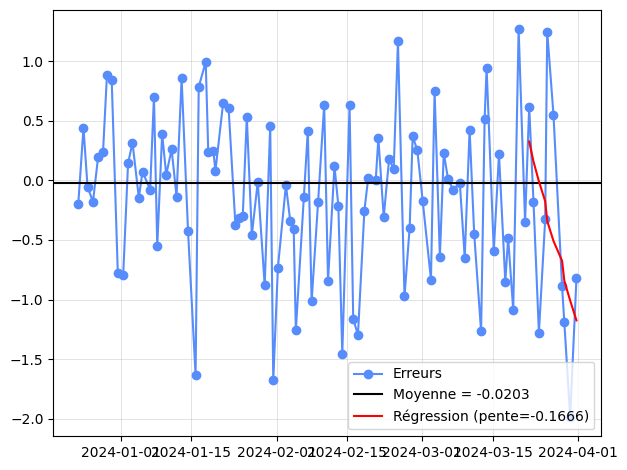

In [1]:
import psycopg
import matplotlib.pyplot as plt
import numpy as np

TARGET_SENSOR = 3

# Connexion BDD
conn = psycopg.connect(host="localhost", dbname="postgres", user="postgres", password="admin")
cursor = conn.cursor()

# 1. Calcul de µ et σ
cursor.execute("""
    SELECT AVG(cm.controlvalue - sm.sensorvalue),
           STDDEV(cm.controlvalue - sm.sensorvalue)
    FROM controlmeasurement cm
    JOIN sensormeasurement sm
      ON cm.sensortimestamp = sm.timestamp
     AND cm.sensorid = sm.sensorid
    WHERE cm.sensorid = %s
""", (TARGET_SENSOR,))

mu, sigma = cursor.fetchone()
mu, sigma = float(mu), float(sigma)
print(f"Moyenne : {mu:.4f} | Écart-type : {sigma:.4f}")

# 2. Récupération des dernières erreurs
cursor.execute("""
    SELECT cm.controlvalue - sm.sensorvalue, cm.controltimestamp
    FROM controlmeasurement cm
    JOIN sensormeasurement sm
      ON cm.sensortimestamp = sm.timestamp
     AND cm.sensorid = sm.sensorid
    WHERE cm.sensorid = %s
    ORDER BY cm.controltimestamp DESC
    LIMIT 100
""", (TARGET_SENSOR,))

rows = list(reversed(cursor.fetchall()))
errors     = [float(row[0]) for row in rows]
timestamps = [row[1]        for row in rows]

# 3. Calcul du seuil par simulation Monte Carlo
slopes = []
x = np.arange(10)

for _ in range(100_000):
    data_sain = np.random.normal(0, sigma, 10)
    pente, _ = np.polyfit(x, data_sain, 1)
    slopes.append(abs(pente))

seuil = np.percentile(slopes, 95)
print(f"Seuil de pente : {seuil:.4f}")

# 4. Régression linéaire sur les 10 derniers points
last_10_errors     = errors[-10:]
last_10_timestamps = timestamps[-10:]

pente, intercept = np.polyfit(x, last_10_errors, 1)
droite = pente * x + intercept

# 5. Alerte dérive
if abs(pente) > seuil:
    print(f"ALERTE : dérive détectée (pente = {pente:.4f})")
else:
    print(f"OK : pas de dérive (pente = {pente:.4f})")

# 6. Graphique
plt.plot(timestamps, errors, marker='o', label='Erreurs')
plt.axhline(mu, color='black', label=f'Moyenne = {mu:.4f}')
plt.plot(last_10_timestamps, droite, color='red', label=f'Régression (pente={pente:.4f})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

cursor.close()
conn.close()

**Analyse de dérive**

La simulation donne un seuil de pente de 0.1432. Or, sur les 10 dernières mesures du capteur 3, la pente trouvée est de 0.1666.

Le seuil est donc dépassé, ce qui confirme qu’il y a bien une dérive. Le capteur 3 ne subit pas seulement des variations aléatoires : son comportement se dégrade progressivement.
Conclusion de l’analyse

Au final, les deux méthodes se complètent bien. Les règles statistiques repèrent les anomalies rapides, tandis que la régression linéaire permet de détecter une dérive plus lente.

Dans le cas du capteur 3, les résultats montrent qu’il faut le surveiller de près, car son comportement s’éloigne peu à peu du fonctionnement normal.